# Notebook 01 — Data Preparation

Freddie Mac Single Family Loan-Level Dataset, 2019 vintage sample.

This notebook lands the raw origination and monthly performance files and produces a single clean, labelled modelling table saved to `data/processed/loans_2019_labeled.parquet`. Downstream notebooks (02 EDA, 03 modelling) consume that parquet directly.

Scope: loading, quality audit, default label construction, join, save.
Out of scope: feature engineering (banding, encoding), splits, modelling, business analysis.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot style
sns.set_theme(style="whitegrid")

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

ORIG_FILE = DATA_RAW / "sample_orig_2019.txt"
PERF_FILE = DATA_RAW / "sample_perf_2019.txt"

assert ORIG_FILE.exists(), f"Origination file not found at {ORIG_FILE}"
assert PERF_FILE.exists(), f"Performance file not found at {PERF_FILE}"

# Reproducibility
SEED = 42

print(f"Origination file: {ORIG_FILE.name} ({ORIG_FILE.stat().st_size / 1e6:.1f} MB)")
print(f"Performance file: {PERF_FILE.name} ({PERF_FILE.stat().st_size / 1e6:.1f} MB)")

Origination file: sample_orig_2019.txt (6.4 MB)
Performance file: sample_perf_2019.txt (213.8 MB)


## 1. Context and objectives

### Business framing

For each mortgage application, a lender faces one decision: approve or reject. A wrong approval costs the loss on default. A wrong rejection costs the margin the lender would have earned on a performing loan. This case study frames credit risk modelling around that trade-off, using the Freddie Mac Single Family Loan-Level Dataset (SFLLD) 2019 vintage sample as the working dataset.

The 2019 vintage is the last full origination year before the COVID shock of 2020 and the rate hikes of 2022. It provides a clean baseline of a healthy US mortgage book, observable over a full early-life window without pandemic noise dominating the first months of loan performance.

### What this notebook produces

This notebook lands the raw SFLLD 2019 sample files (`sample_orig_2019.txt` and `sample_perf_2019.txt`), audits their quality, constructs a default label (`default_24m`: ever 90+ days past due within the first 24 months of the loan's life), and saves a single clean modelling table to `data/processed/loans_2019_labeled.parquet`. One row per loan, origination features plus label.

### What this notebook does not do

No feature engineering (no banding of continuous variables, no encoding of categoricals). No train/test splits. No modelling. No exploratory analysis of the portfolio composition. Those live in notebooks 02 and 03.

## 2. Loading the origination file

The origination file follows the Freddie Mac Standard Dataset layout (post-2023 revision). It has no header row, pipe-separated, 31 positional columns. One row per loan.

We load all 31 columns with their standard names and provisional dtypes. Column-level pruning is deferred to section 3, after the quality audit tells us what each column actually contains in this sample.

### 2.1 Column layout

The 31 columns and their roles, based on the Freddie Mac SFLLD User Guide (Standard Dataset layout):

| Position | Column                          | Type    | Kept for modelling? |
|----------|----------------------------------|---------|---------------------|
| 1        | CREDIT_SCORE                     | numeric | yes                 |
| 2        | FIRST_PAYMENT_DATE               | YYYYMM  | yes (timing filter) |
| 3        | FIRST_TIME_HOMEBUYER_FLAG        | Y/N     | yes                 |
| 4        | MATURITY_DATE                    | YYYYMM  | no                  |
| 5        | MSA                              | numeric | drop (postal-level) |
| 6        | MI_PCT                           | numeric | yes                 |
| 7        | NUM_UNITS                        | numeric | yes                 |
| 8        | OCCUPANCY_STATUS                 | P/S/I   | yes                 |
| 9        | OCLTV                            | numeric | yes                 |
| 10       | DTI                              | numeric | yes                 |
| 11       | ORIGINAL_UPB                     | numeric | yes                 |
| 12       | LTV                              | numeric | yes                 |
| 13       | ORIGINAL_INTEREST_RATE           | numeric | yes                 |
| 14       | CHANNEL                          | R/B/C/T | yes                 |
| 15       | PREPAYMENT_PENALTY_FLAG          | Y/N     | drop (constant)     |
| 16       | AMORTIZATION_TYPE                | FRM/ARM | drop (filter only)  |
| 17       | PROPERTY_STATE                   | 2-char  | yes (grouped)       |
| 18       | PROPERTY_TYPE                    | code    | yes                 |
| 19       | POSTAL_CODE                      | 3-digit | drop                |
| 20       | LOAN_SEQUENCE_NUMBER             | string  | yes (join key)      |
| 21       | LOAN_PURPOSE                     | P/C/N   | yes                 |
| 22       | ORIGINAL_LOAN_TERM               | numeric | yes                 |
| 23       | NUMBER_OF_BORROWERS              | numeric | yes                 |
| 24       | SELLER_NAME                      | string  | drop                |
| 25       | SERVICER_NAME                    | string  | drop                |
| 26       | SUPER_CONFORMING_FLAG            | Y/N     | drop                |
| 27       | PRE_HARP_LOAN_SEQUENCE_NUMBER    | string  | drop                |
| 28       | PROGRAM_INDICATOR                | code    | drop                |
| 29       | HARP_INDICATOR                   | Y/N     | drop                |
| 30       | PROPERTY_VALUATION_METHOD        | code    | drop                |
| 31       | INTEREST_ONLY_INDICATOR          | Y/N     | drop                |

The "keep" decisions above are provisional. Some may change after the section 3 audit if a column proves too sparse or too constant to be useful.

In [4]:
from src.loaders import FreddieMacLoader

loader = FreddieMacLoader(data_raw=DATA_RAW)
orig = loader.load_origination()

print(f"Loaded origination file: {orig.shape[0]:,} rows × {orig.shape[1]} columns")
print(f"Memory footprint: {orig.memory_usage(deep=True).sum() / 1e6:.1f} MB")

orig.head()

Loaded origination file: 50,000 rows × 31 columns
Memory footprint: 15.3 MB


,credit_score,first_payment_date,first_time_homebuyer_flag,maturity_date,msa,mi_pct,num_units,occupancy_status,ocltv,dti,original_upb,ltv,original_interest_rate,channel,prepayment_penalty_flag,amortization_type,property_state,property_type,postal_code,loan_sequence_number,loan_purpose,original_loan_term,number_of_borrowers,seller_name,servicer_name,super_conforming_flag,pre_harp_loan_sequence_number,program_indicator,harp_indicator,property_valuation_method,interest_only_indicator
0,741.00,201903,N,204902,<NA>,0.00,1.00,P,80.00,33.00,372000.00,80.00,5.12,R,N,FRM,WY,SF,824,F19Q10000056,P,360.00,2.00,OTHER,N,NaN,NaN,N,7,N,9999
1,731.00,201903,N,204902,13460,0.00,1.00,P,77.00,44.00,250000.00,77.00,4.88,R,N,FRM,OR,SF,977,F19Q10000060,P,360.00,1.00,OTHER,N,NaN,NaN,N,7,N,9999
2,722.00,201903,N,204902,<NA>,30.00,1.00,P,95.00,41.00,261000.00,95.00,5.50,R,N,FRM,IN,SF,467,F19Q10000084,P,360.00,2.00,OTHER,N,NaN,NaN,N,7,N,9999
3,729.00,201903,N,204902,<NA>,25.00,1.00,P,87.00,17.00,61000.00,87.00,5.09,R,N,FRM,MI,SF,498,F19Q10000106,P,360.00,1.00,OTHER,N,NaN,NaN,N,7,N,9999
4,773.00,201903,N,204902,33700,0.00,1.00,P,29.00,43.00,390000.00,29.00,5.38,R,N,FRM,CA,SF,953,F19Q10000189,C,360.00,2.00,OTHER,N,NaN,NaN,N,7,N,9999


## 3. Origination quality audit

Before any decision on which columns to keep and which to drop, we audit what the file actually contains: missing values, sentinel codes, distributions of continuous and categorical variables, and uniqueness of the join key. Each subsection ends on a short takeaway. Decisions on which columns to drop from the final modelling table are consolidated at the end of the section.

### 3.1 Missing values

First pass: how many NaN per column, in absolute count and percentage. This surfaces columns that are almost entirely empty and can be dropped without further analysis.

In [5]:
missing = pd.DataFrame({
    "n_missing": orig.isna().sum(),
    "pct_missing": (orig.isna().mean() * 100).round(2),
})
missing = missing[missing["n_missing"] > 0].sort_values("pct_missing", ascending=False)
missing

,n_missing,pct_missing
super_conforming_flag,49970,99.94
pre_harp_loan_sequence_number,45317,90.63
msa,4574,9.15


**Takeaway.** Three columns have visible missing values:

- `super_conforming_flag` (99.94 % missing) is a jumbo-loan indicator that only fires on ~30 loans in the sample. Not exploitable as a feature, will be dropped.
- `pre_harp_loan_sequence_number` (90.63 % missing) identifies refinances of pre-HARP loans. Irrelevant for underwriting a new loan, will be dropped.
- `msa` (9.15 % missing) is not a true missing: an empty value means the property is outside any Metropolitan Statistical Area (rural or small-town). Kept as a feature with an explicit "no MSA" category to be built later.

All other columns show zero visible NaN, but several use numeric sentinel codes (`9999`, `999`, `9`) for "unknown", which the naive missing-value count does not detect. These are audited in the next subsection.

### 3.2 Sentinel values

Freddie Mac encodes "unknown" values as numeric or string sentinels rather than as NaN. The most common codes in the Standard Dataset layout are `9999`, `999`, `99`, `9` (for numeric fields), and `XX` (for state). Left untreated, these sentinels are counted as valid values and pollute every downstream statistic (means, distributions, model inputs).

We replace them with NaN so that all "unknown" values are missing in the pandas sense from this point onward. Two exceptions:

- `harp_indicator = 7` means "not a HARP loan", it is a valid category, not a sentinel. Column is dropped anyway.
- `mi_pct = 0` means "no mortgage insurance on this loan", it is a valid value. Only `mi_pct = 999` is the true unknown.

In [11]:
# Mapping: column -> sentinel value(s) meaning "unknown"
SENTINELS = {
    "credit_score": [9999],
    "dti": [999],
    "mi_pct": [999],
    "num_units": [99],
    "original_loan_term": [999],
    "number_of_borrowers": [99],
    "first_time_homebuyer_flag": ["9"],
    "occupancy_status": ["9"],
    "channel": ["9"],
    "property_state": ["XX"],
    "property_type": ["99"],
    "loan_purpose": ["9"],
    "ocltv": [999],
}

# Count how many rows are affected per column, before replacing anything
impact = []
for col, values in SENTINELS.items():
    n = orig[col].isin(values).sum()
    pct = n / len(orig) * 100
    impact.append({"column": col, "sentinels": values, "n_affected": n, "pct_affected": round(pct, 2)})

impact_df = pd.DataFrame(impact).sort_values("n_affected", ascending=False)
impact_df

,column,sentinels,n_affected,pct_affected
12,ocltv,[999],1,0.00
0,credit_score,[9999],0,0.00
1,dti,[999],0,0.00
2,mi_pct,[999],0,0.00
3,num_units,[99],0,0.00
4,original_loan_term,[999],0,0.00
5,number_of_borrowers,[99],0,0.00
6,first_time_homebuyer_flag,[9],0,0.00
7,occupancy_status,[9],0,0.00
8,channel,[9],0,0.00


In [12]:
# Apply the replacement in place. From here on, all "unknown" values are true NaN.
for col, values in SENTINELS.items():
    orig[col] = orig[col].replace(values, np.nan)

# Verify: NaN count after replacement on the affected columns
affected_cols = ["credit_score", "dti"]
orig[affected_cols].isna().sum()

credit_score    18
dti             31
dtype: int64

**Takeaway.** The 2019 sample is remarkably clean on sentinel codes. Only two columns are affected:

- `credit_score`: 18 loans (0.04 %) with FICO unknown, now NaN.
- `dti`: 31 loans (0.06 %) with DTI unknown, now NaN.

All other audited columns contain no sentinel values in this sample. The 49 loans with a newly-NaN feature will be either excluded or imputed at modelling time (notebook 03); the decision is deferred because it depends on the modelling strategy chosen.

### 3.3 Continuous distributions

Six continuous features carry the underwriting signal at origination: FICO (`credit_score`), LTV, OCLTV, DTI, original UPB, and the note rate (`original_interest_rate`). We check their distributions to confirm the ranges are plausible for a 2019 US mortgage vintage and to spot out-of-range values that would betray corrupted data.

Two viewing angles:
- A `.describe()` table on all six, for quantiles and extremes.
- A 2×2 histogram grid on FICO, LTV, DTI, and note rate. UPB is skipped from the grid (log-normal, harder to read raw) and read from the quantile table.

In [13]:
continuous_cols = [
    "credit_score",
    "ltv",
    "ocltv",
    "dti",
    "original_upb",
    "original_interest_rate",
]

orig[continuous_cols].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).round(2)

,credit_score,ltv,ocltv,dti,original_upb,original_interest_rate
count,49982.00,50000.00,49999.00,49969.00,50000.00,50000.00
mean,749.39,75.64,75.82,35.31,254574.78,4.24
std,44.01,16.81,16.81,9.37,130080.10,0.59
min,562.00,5.00,5.00,1.00,15000.00,2.35
1%,635.00,24.00,25.00,12.00,51000.00,3.00
25%,719.00,69.00,69.00,29.00,155000.00,3.88
50%,757.00,80.00,80.00,37.00,232000.00,4.12
75%,785.00,90.00,90.00,43.00,335000.00,4.62
99%,816.00,97.00,97.00,50.00,645000.00,5.88
max,832.00,103.00,105.00,50.00,1397000.00,6.75


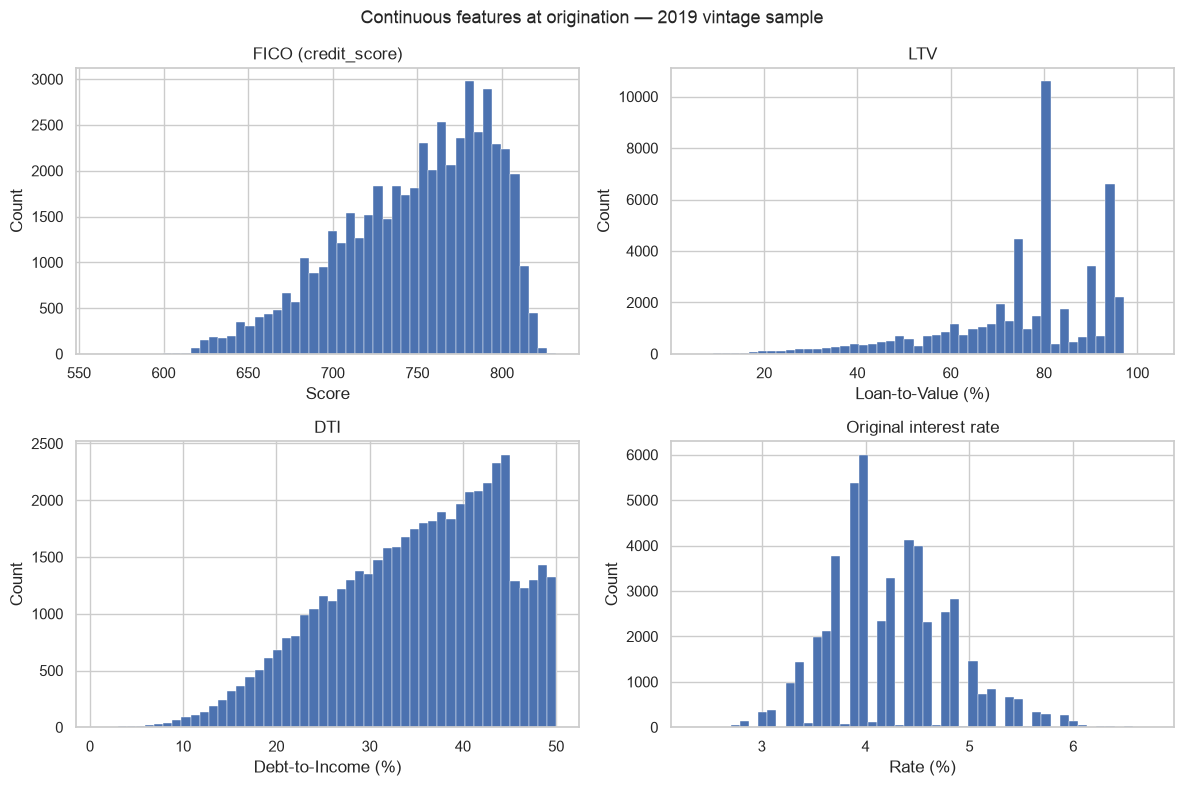

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(orig["credit_score"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[0, 0].set_title("FICO (credit_score)")
axes[0, 0].set_xlabel("Score")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(orig["ltv"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[0, 1].set_title("LTV")
axes[0, 1].set_xlabel("Loan-to-Value (%)")
axes[0, 1].set_ylabel("Count")

axes[1, 0].hist(orig["dti"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[1, 0].set_title("DTI")
axes[1, 0].set_xlabel("Debt-to-Income (%)")
axes[1, 0].set_ylabel("Count")

axes[1, 1].hist(orig["original_interest_rate"].dropna(), bins=50, edgecolor="white", linewidth=0.3)
axes[1, 1].set_title("Original interest rate")
axes[1, 1].set_xlabel("Rate (%)")
axes[1, 1].set_ylabel("Count")

fig.suptitle("Continuous features at origination — 2019 vintage sample", fontsize=13)
fig.tight_layout()
plt.show()

**Takeaway.** Six continuous features audited. The vintage 2019 sample is consistent with expectations for a US prime mortgage book:

- FICO ranges 562-832, median 757, distribution skewed left as expected for a GSE portfolio (very few subprime loans).
- LTV shows the classic multi-modal shape driven by PMI avoidance at 80 % and the 90 / 95 / 97 % program tiers. A continuous left tail extends down to 5 % (~250 loans, likely cash-out or rate/term refis on well-amortised properties), kept as-is.
- DTI hard-capped at 50, consistent with the qualified mortgage rule.
- UPB ranges 15k-1.4M, median 232k, consistent with 2019 conforming loan limits.
- Interest rates 2.35-6.75 %, median 4.12 %, consistent with the 2019 rate environment.

The audit surfaced one sentinel code missed in section 3.2: `ocltv = 999` (one loan), added to the sentinel dictionary and replaced with NaN. All continuous variables now have distributions and ranges ready for downstream modelling.